# Grid Network Analysis - Week 2, Task 2.3: Business Intelligence and Reliability Analysis

**Scope**: Part A Task 2.3 only. All metrics below are explicit **proxies** -
the synthetic dataset has no real load, population, or outage-history data,
so "risk", "growth opportunity", and "reliability" are structural
stand-ins built from capacity, age, maintenance status, and network
centrality (from Task 2.1) - not verified operational findings.

All logic lives in `../src/bi.py` (unit tested in `../tests/test_bi.py`).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("..").resolve()))
from src.cleaning import load_raw, clean_and_validate, merge_all
from src.network import build_graph, compute_centrality
from src.bi import (
    utility_infrastructure_footprint, capacity_utilization_flags,
    line_maintenance_proportion, asset_age_profile, capacity_concentration,
    growth_opportunities, reliability_proxy,
)

DATA_DIR = Path("../data")
CHARTS_DIR = Path("../outputs/charts")
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

utilities, substations, lines = load_raw(DATA_DIR)
utilities, substations, lines, _ = clean_and_validate(utilities, substations, lines)
merged = merge_all(utilities, substations, lines)

## Utility Footprint Analysis

Which utility operates the most infrastructure, broken down by region and
by voltage tier.

In [2]:
footprint_by_region, footprint_by_voltage = utility_infrastructure_footprint(merged)
footprint_by_region.head(10)

,Utility Alias,Source Region,Line Count
13,GRIDCo,Greater Accra,5
21,NEDCo,Greater Accra,4
19,NEDCo,Central,3
18,NEDCo,Ashanti,3
17,GRIDCo,Western,3
16,GRIDCo,Volta,3
12,GRIDCo,Eastern,3
10,GRIDCo,Bono,3
8,ECG,Western,2
9,GRIDCo,Ashanti,2


In [3]:
footprint_by_voltage

Voltage (kV),11,33,69,161,330
Utility Alias,,,,,
CEB,0,0,0,0,3
CIE,0,0,0,0,2
ECG,3,3,2,1,1
GRIDCo,5,3,3,4,9
NEDCo,6,2,4,2,0
SONABEL,0,0,0,0,2


## Capacity Utilization Mapping

Substations and lines whose capacity sits in the bottom or top quartile
for their voltage tier - a proxy for "upgrade candidate" (low) vs
"over-provisioned" (high).

In [4]:
sub_flags, line_flags = capacity_utilization_flags(substations, lines)
print("Substations flagged as upgrade candidates or high-capacity:")
sub_flags[sub_flags["capacity_flag"] != "Typical"]

Substations flagged as upgrade candidates or high-capacity:


,Substation ID,Name,Region,Capacity (MVA),Voltage (kV),capacity_flag
0,1,Achimota Substation,Greater Accra,6.4,11,Low capacity (upgrade candidate)
1,2,Tema Substation,Greater Accra,48.5,330,Low capacity (upgrade candidate)
2,3,Mallam Substation,Greater Accra,25.2,330,Low capacity (upgrade candidate)
4,5,Kaneshie Substation,Greater Accra,146.0,161,Low capacity (upgrade candidate)
5,6,Aboadze Junction Substation,Greater Accra,52.2,161,Low capacity (upgrade candidate)
7,8,Ejisu Substation,Ashanti,355.9,330,High capacity
8,9,Obuasi Substation,Ashanti,47.5,33,High capacity
11,12,Takoradi Substation,Western,14.0,33,Low capacity (upgrade candidate)
15,16,Cape Coast Substation,Central,68.8,69,Low capacity (upgrade candidate)
17,18,Kasoa Substation,Central,52.4,11,High capacity


In [5]:
print("Lines flagged as upgrade candidates or high-capacity:")
line_flags[line_flags["capacity_flag"] != "Typical"]

Lines flagged as upgrade candidates or high-capacity:


,Line ID,Source Substation,Destination Substation,Capacity (MVA),Voltage (kV),capacity_flag
1,2,Achimota Substation,Mallam Substation,36.4,11,Low capacity (upgrade candidate)
3,4,Tema Substation,Mallam Substation,39.0,330,Low capacity (upgrade candidate)
6,7,Mallam Substation,Kaneshie Substation,108.5,161,Low capacity (upgrade candidate)
7,8,Mallam Substation,Aboadze Junction Substation,298.9,161,High capacity
8,9,Legon Substation,Kaneshie Substation,266.6,161,High capacity
10,11,Kumasi Central Substation,Mampong Substation,269.1,69,High capacity
14,15,Obuasi Substation,Konongo Substation,284.6,33,High capacity
15,16,Mampong Substation,Konongo Substation,61.5,69,Low capacity (upgrade candidate)
16,17,Takoradi Substation,Aboadze Substation,78.8,33,Low capacity (upgrade candidate)
20,21,Tarkwa Substation,Axim Substation,264.2,69,High capacity


## Reliability Metrics

### Proportion of lines under maintenance, by region and utility

In [6]:
maint_by_region, maint_by_utility = line_maintenance_proportion(merged)
maint_by_region

,Source Region,under_maintenance_rate
3,Central,0.166667
6,Greater Accra,0.090909
0,Ashanti,0.000000
1,Bono,0.000000
2,Burkina Faso border,0.000000
4,Cote d'Ivoire border,0.000000
5,Eastern,0.000000
7,Northern,0.000000
8,Togo,0.000000
9,Togo border,0.000000


In [7]:
maint_by_utility

,Utility Alias,under_maintenance_rate
2,ECG,0.100000
3,GRIDCo,0.041667
0,CEB,0.000000
1,CIE,0.000000
4,NEDCo,0.000000
5,SONABEL,0.000000


### Asset age profile

Older assets are used here as a fault-risk proxy - the assumption being
that, all else equal, older infrastructure is more likely to need
attention than newer infrastructure.

In [8]:
age_profile = asset_age_profile(substations)
age_profile

,decade,substation_count,avg_capacity_mva,active_rate
0,1960s,2,40.050000,0.5
1,1970s,8,131.262500,1.0
2,1980s,4,197.425000,1.0
3,1990s,8,221.725000,1.0
4,2000s,11,161.345455,1.0
5,2010s,9,152.833333,1.0
6,2020s,2,51.050000,1.0


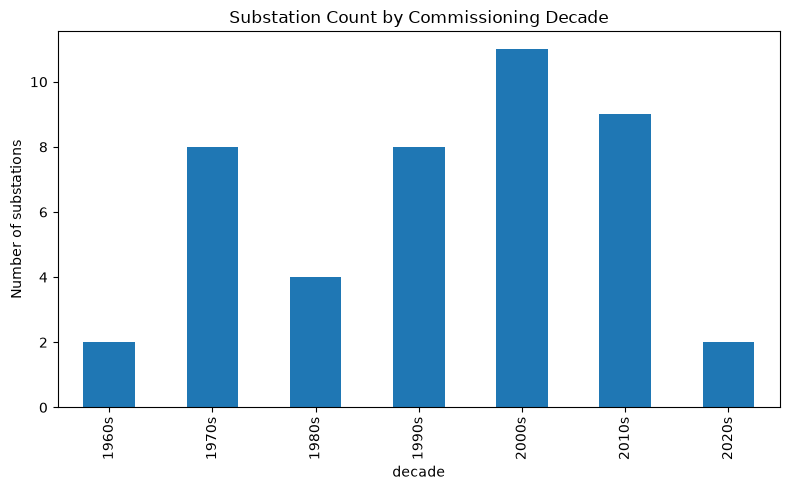

In [9]:
age_profile.plot(x="decade", y="substation_count", kind="bar", figsize=(8, 5),
                  title="Substation Count by Commissioning Decade", legend=False)
plt.ylabel("Number of substations")
plt.tight_layout()
plt.savefig(CHARTS_DIR / "asset_age_profile.png")
plt.show()

### Capacity concentration (risk indicator)

What share of total rated capacity sits in a small number of substations -
the more concentrated, the more a single substation's loss could matter,
echoing the N-1 finding from Task 2.1 but from a capacity angle rather
than a connectivity angle.

In [10]:
concentration = capacity_concentration(substations, top_fraction=0.1)
concentration

{'top_fraction': 0.1,
 'num_substations_in_top_fraction': 4,
 'share_of_total_capacity': 0.2513}

## Growth Opportunities

Regions with both substation count and total capacity at or below the
cross-region median - the best available proxy for "growth opportunity"
without real population or demand data.

In [11]:
opportunities = growth_opportunities(substations)
opportunities

,Region,substation_count,total_capacity_mva,growth_opportunity
4,Burkina Faso border,1,156.1,True
6,Cote d'Ivoire,1,262.6,True
7,Cote d'Ivoire border,1,285.1,True
10,Guinea,1,251.6,True
12,Togo,1,120.2,True
15,Upper West,1,27.1,True
1,Benin,1,487.6,False
3,Burkina Faso,1,445.9,False
13,Togo border,1,423.2,False
14,Upper East,2,520.7,False


## Reliability Proxy Analysis

Combines asset age, whether a substation currently has a line under
maintenance, and network betweenness centrality (from Task 2.1's
`../src/network.py`) into one composite reliability-risk proxy score per
substation. This deliberately ties together findings from Task 1
(cleaning), Task 2.1 (network), and Task 2.3 (BI) into a single view -
framed explicitly as a proxy, not a fault-probability model.

In [12]:
G = build_graph(substations, lines)
centrality = compute_centrality(G)

risk = reliability_proxy(substations, merged, centrality=centrality)
risk.head(10)

,Substation ID,Name,Region,age_years,Status,lines_under_maintenance,betweenness_centrality,reliability_risk_score
15,16,Cape Coast Substation,Central,34,Active,1,0.525471,0.6738
2,3,Mallam Substation,Greater Accra,47,Active,1,0.054448,0.5563
30,31,Tamale Substation,Northern,57,Inactive,0,0.238095,0.3843
11,12,Takoradi Substation,Western,26,Active,0,0.516058,0.3264
23,24,Ho Substation,Volta,30,Active,0,0.436323,0.3163
12,13,Aboadze Substation,Western,59,Active,0,0.021595,0.3086
4,5,Kaneshie Substation,Greater Accra,56,Active,0,0.012551,0.2887
16,17,Winneba Substation,Central,56,Active,0,0.000000,0.2836
34,35,Bawku Substation,Upper East,55,Active,0,0.000000,0.2782
14,15,Axim Substation,Western,52,Active,0,0.000000,0.2618


## Business intelligence dashboard summary / strategic recommendations

(Task 2.3 deliverables: a business-intelligence dashboard, reliability
report, capacity/growth visualization, and strategic recommendations. The
tables and charts above already function as that dashboard within this
notebook; the interactive Streamlit dashboard in `../dashboard.py`
surfaces the same functions for live exploration - see Task 3.1.)

- The utility footprint tables show which utility to engage first for any
  region-specific infrastructure conversation.
- The capacity-utilization flags identify concrete upgrade-candidate
  substations/lines worth prioritizing in a capital-planning discussion.
- The reliability proxy score gives one ranked list combining age,
  maintenance status, and structural importance - a reasonable starting
  point for prioritizing inspection/maintenance budget, with the explicit
  caveat that it is not a substitute for real condition-monitoring data.

## Notes and limitations

Every metric in this notebook is a **proxy** built from the synthetic
dataset's capacity, age, region, and status fields - none of it should be
read as a verified engineering or operational finding. See
`../../docs/architecture-diagrams/grid-analysis-data-dictionary.md` for the
underlying data's description and limitations.